## 실무상황 ML 시뮬레이션 하기

### 1) 역할 설정
- 당신은 금융플랫폼 회사에서 보험 중개 제품을 맡은 데이터 분석가입니다
- 당신의 보험 제품에는 총 5가지 서비스가 있으며, 모든 서비스는 제휴사 가입 퍼널로 이어지도록 만들어져 있습니다
- 당신의 팀은 어떤 서비스를 전면에 내세워야 할지 고민하고 있으며, 비즈니스 성과에 각 서비스들이 얼마나 기여하는지 궁금해 하고 있습니다.
- 어떤 서비스를 제품의 핵심 서비스로 키울지에 대한 분석 인사이트를 SHAP으로 만들어 보세요

### 2) Data
- 데이터는 일자 및 서비스 별 방문자 수가 있습니다
- bnft_user_cnt: 유저의 행동에 따라 리워드를 지급하는 혜택성 지면입니다. (마이데이터 가입시 n원, 보험 상품 조회시 n원 등)
- lck_comp_user_cnt: 유저의 보험료와 보장 데이터를 활용하여 가입한 보험의 가성비를 평가해주는 지면입니다.
- bridge_user_cnt: 외부 채널에서 유저의 보험 가입을 위한 마케팅을 할 때, 유저를 랜딩 시키는 브릿지 화면입니다. 버튼을 누르는 즉시 보험 가입 페이지로 이동하며 보험 가입을 완료하면 리워드를 받을 수 있는 혜택성 지면입니다.
- detail_user_cnt: 유저의 보험 정보를 조회할 수 있는 정보성 지면입니다. (보험료, 보장내역, 가입정보 등)
- r_fee_user_cnt: 유저의 보험금을 보험 대리점을 통해 청구할 수 있는 보험금 간편 청구 서비스 지면입니다.
- cm_user_cnt: 보험 가입 지면입니다. (종속변수)


즉 5가지의 feature로 cm_user_cnt를 예측하고 XAI인 shap을 통해 설명해보자.

### 3) Analyzation & Visualization Guide
- 3가지 그래프를 차팅하세요(변수별 기여도(영향도)를 확인할 수 있는 차트, 변수 값의 크기에 따라 shap_value를 확인할 수 있는 차트, Dependence Plot)
- 3가지 그래프를 활용해 어떤 서비스를 제품 전면에 내세울지 의사결정을 해보세요.
- 타 직무의 팀원들은 ML에 대한 이해도가 없어 Shap 분석을 이해하기 어렵습니다. 가장 성과가 좋았던 날과, 가장 좋지 않았던 날에 대한 Waterfall 차트를 활용해 shap 분석에 대한 개념을 팀원들에게 설명해주세요

In [15]:
import pandas as pd
import numpy as np
import shap
import xgboost

from sklearn import preprocessing
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

In [10]:
df = pd.read_csv('../data/ML_data.csv')
df

,partition_day,bnft_user_cnt,lck_comp_user_cnt,bridge_user_cnt,detail_user_cnt,r_fee_user_cnt,cm_user_cnt
0,2023-07-01,1626,71,4464,82,29,489
1,2023-07-02,1959,86,4882,466,37,525
2,2023-07-03,1360,12,1245,494,42,473
3,2023-07-04,1794,79,4247,228,10,501
4,2023-07-05,1630,81,4110,476,48,515
...,...,...,...,...,...,...,...
179,2023-12-27,689,36,2687,50,23,444
180,2023-12-28,1748,11,2931,436,25,502
181,2023-12-29,1908,99,3737,397,9,511
182,2023-12-30,1900,26,4746,239,22,506


In [11]:
#모델링
exp_v = df.iloc[:, 1:6] 
tar_v = df[['cm_user_cnt']]

shap.initjs()

#예측은 xgboost로 
model = xgboost.XGBRFRegressor().fit(exp_v, tar_v)

explainer = shap.Explainer(model)
shap_value = explainer(exp_v)

In [32]:
shap_value

.values =
array([[ 9.94665051e+00,  2.65682608e-01,  1.20155096e+01,
        -1.17834816e+01, -3.42500880e-02],
       [ 1.67410965e+01,  3.65592569e-01,  1.63699245e+01,
         1.14400949e+01,  2.86862552e-01],
       [ 3.44379544e+00, -3.88207793e-01, -1.89912395e+01,
         9.12681007e+00, -5.73840924e-04],
       [ 1.15028706e+01,  2.82957435e-01,  1.20495234e+01,
        -2.76348376e+00,  5.10634109e-02],
       [ 1.04792442e+01,  9.88387838e-02,  1.17784748e+01,
         1.08029499e+01,  6.05084226e-02],
       [ 8.69501781e+00, -3.54026305e-03, -5.18835306e+00,
        -7.31143284e+00, -1.24186866e-01],
       [ 7.76031685e+00,  1.09028695e-02, -2.54641724e+00,
         5.28424072e+00,  2.55974382e-02],
       [-1.92708206e+01,  4.94027138e-02,  7.92921591e+00,
         8.70420647e+00,  1.98388904e-01],
       [-8.86762428e+00,  8.97193104e-02, -1.52829628e+01,
        -1.03085632e+01, -2.53492117e-01],
       [ 9.91560459e+00,  3.88410944e-03,  5.06716061e+00,
         9.79

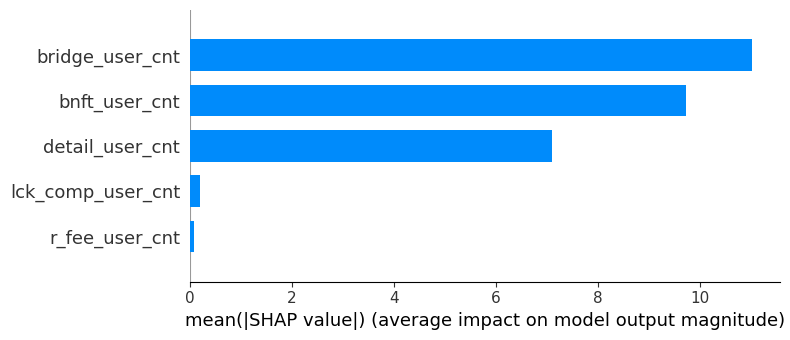

In [12]:
#기여도(중요도) 차팅
shap.summary_plot(shap_value, exp_v, plot_type='bar')

중요도: 브릿지(혜택성) 화면 >> 베네핏(혜택성) 화면 >> 디테일(정보성) 화면

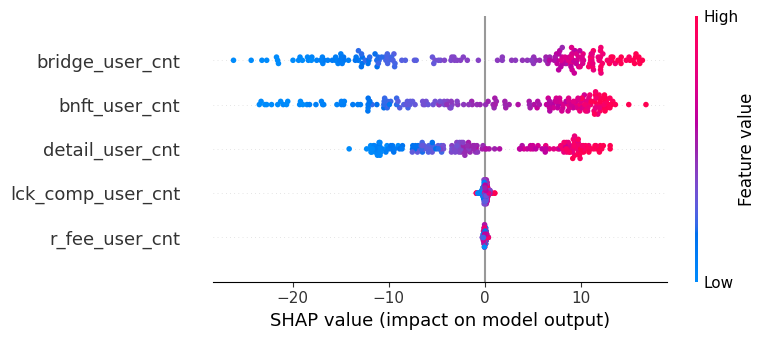

In [13]:
# 변수 별 shap value 차팅
shap.summary_plot(shap_value, exp_v)

- 모든 화면 노출수가 보험가입 유저수에 있어 양의 상관관계를 지닌다
- 브릿지, 베네핏, 디테일 화면 순으로 그 영향도가 크다

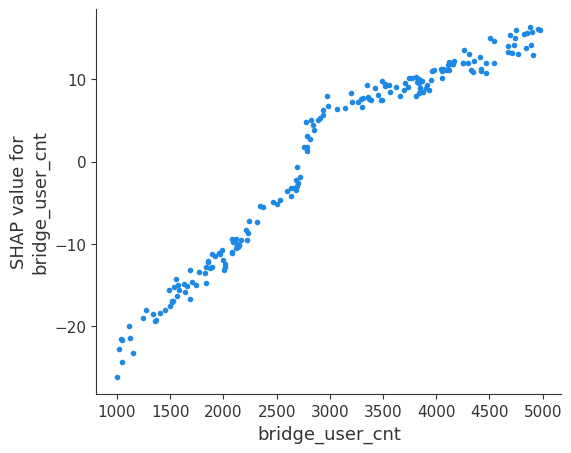

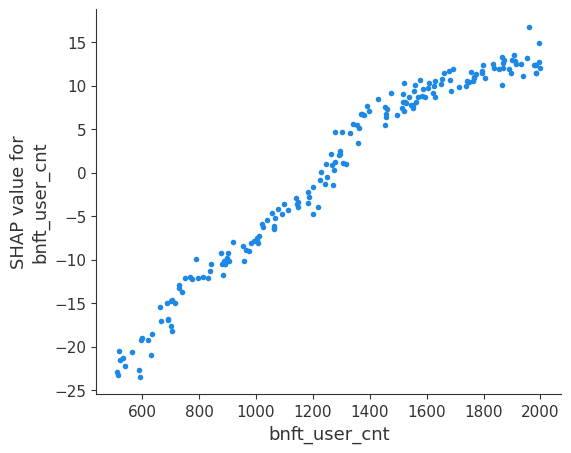

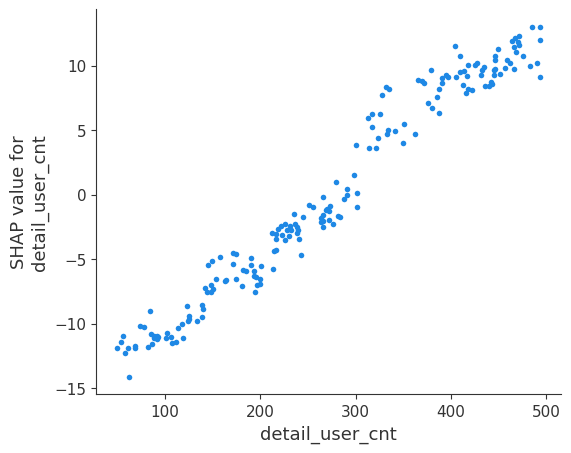

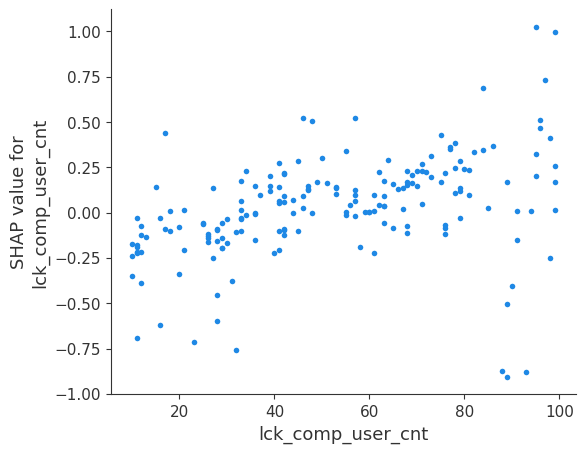

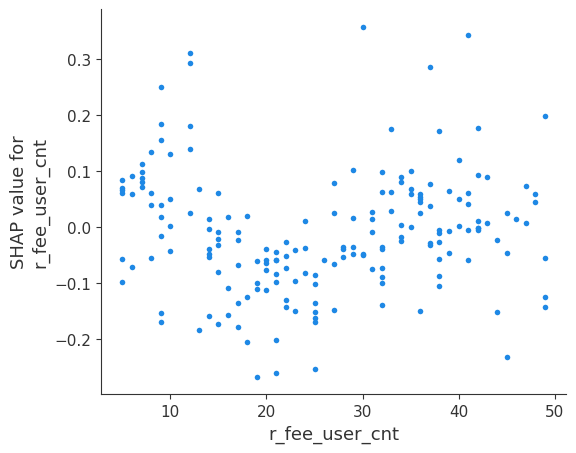

In [16]:
# dependence plot 차팅
top_features = np.argsort(-np.sum(np.abs(shap_value.values), 0))

for i in range(5):
  shap.dependence_plot(top_features[i], shap_value.values, exp_v, interaction_index=None)

 **수확 체감의 법칙(Law of Diminishing Returns)**
 - 처음에는 투입을 늘릴수록 성과가 크게 오르지만, 어느 시점부터 같은 양을 투입해도 성과 증가폭이 점점 줄어드는 현상

 ex) 마케팅 광고비 → 처음 100만원 쓰면 유저 500명 유입, 다음 100만원엔 300명, 그 다음엔 100명... 점점 효율이 떨어짐

푸시 알림 → 처음 보내면 전환율이 확 오르는데, 너무 자주 보내면 오히려 유저가 알림을 끄거나 이탈

기능 추가 → 핵심 기능 1~2개는 리텐션에 큰 영향을 주지만, 기능을 10개 20개 추가한다고 리텐션이 비례해서 오르진 않음

- 혜택성 화면에는 성장체감(성장 둔화)이 보였다
- 반면에 정보성 화면(디테일 화면)에는 성장체감(성장 둔화)이 덜했다
- 그러므로 정보성 화면을 우리 제품의 전면에 내세우는 것이 적절한 의사결정으로 보인다

### 가장 성과가 좋은날 / 나쁜날로 다른 유관 부서의 직원들에게 쉽게 설명해보기

In [27]:
print(df[df['cm_user_cnt'] == df['cm_user_cnt'].min()]['partition_day'].index[0])
print(df[df['cm_user_cnt'] == df['cm_user_cnt'].max()]['partition_day'].index[0])

62
1


In [17]:
# 가장 성과가 좋은 날
max_index = df[df['cm_user_cnt'] == df['cm_user_cnt'].max()]['partition_day'].index[0]

# 가장 성과가 나쁜 날
min_index = df[df['cm_user_cnt'] == df['cm_user_cnt'].min()]['partition_day'].index[0]

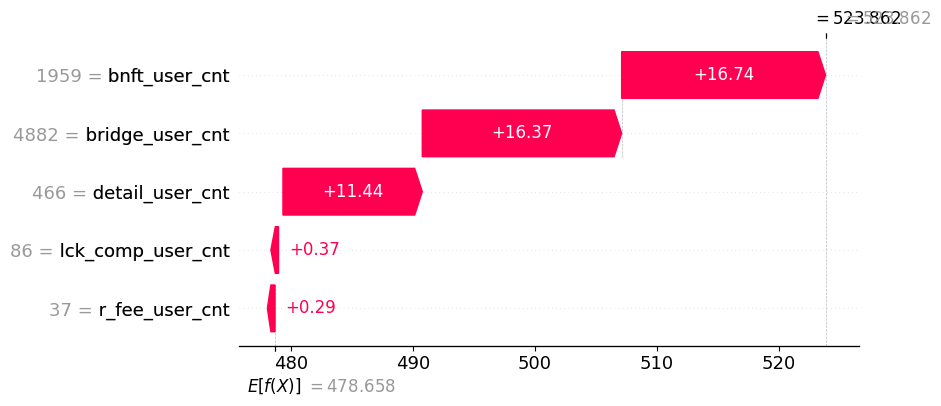

In [ ]:
# water fall 차팅으로 설명(가장 좋은 날)
shap.plots.waterfall(shap_value[max_index])

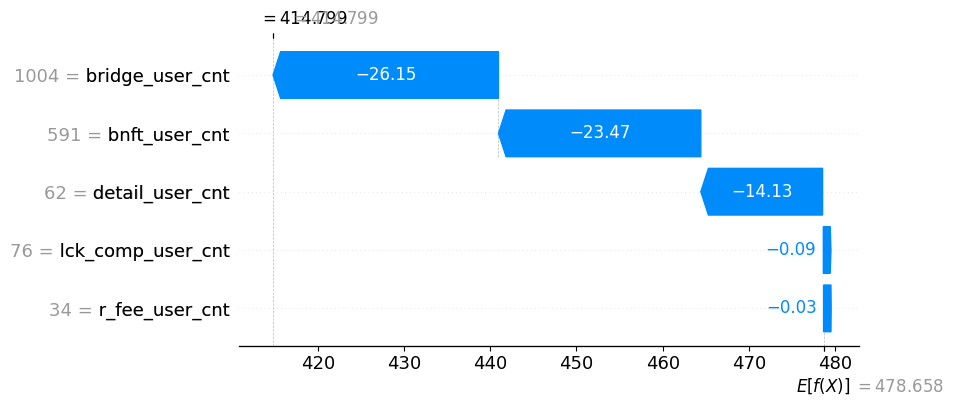

In [29]:
# water fall 차팅으로 설명(가장 나쁜 날)
shap.plots.waterfall(shap_value[min_index])